# Testing Lottery Predictability with Python and Monte Carlo Simulation

## Portfolio project

This project investigates whether historical lottery results contain stable,
out-of-sample predictive information. It uses official Quina results to build
and evaluate an experimental ranking model based on historical frequency,
recent frequency, and the number of draws since each number last appeared.

The analytical workflow includes:

- API-based data updates and validation;
- descriptive frequency and pair analysis;
- leakage-safe walk-forward model selection;
- an independent 200-draw historical holdout;
- prospective monitoring on genuinely unseen draws; and
- Monte Carlo comparison with random selection.

### Main finding

The frozen 45% historical-frequency, 45% recent-frequency, and 10% gap model
performed above the random benchmark during the historical holdout. That
advantage was not reproduced during the first 19 prospective draws. The study
therefore found no stable evidence that these historical features reliably
predict future Quina results.

> **Educational disclaimer:** This repository is a statistical-learning project,
> not gambling advice. Model scores and simulated selections are not official
> winning probabilities. In a fair Quina draw, every exact five-number
> combination has the same jackpot probability: 1 in 24,040,016.


## Notebook roadmap

1. Data setup, update, and validation
2. Descriptive frequency and pair analysis
3. Walk-forward model selection
4. Independent 200-draw holdout validation
5. Genuine forward monitoring
6. Monte Carlo random benchmark
7. Experimental number selection
8. Client conclusion and export


## 0. Setup and load saved data


In [ ]:
import ast
import os
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.stats import binom, chisquare, norm


# Portable project paths. Set QUINA_DATA_FILE to override the default location.
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
IMAGE_DIR = PROJECT_ROOT / "images"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

for directory in (DATA_DIR, IMAGE_DIR, OUTPUT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DATA_FILE = Path(
    os.getenv("QUINA_DATA_FILE", str(DATA_DIR / "quina_complete.csv"))
)

BASE_API = "https://servicebus2.caixa.gov.br/portaldeloterias/api/quina"

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Dataset: {DATA_FILE.resolve()}")


In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_FILE.resolve()}\n"
        "Place quina_complete.csv in the data/ directory or set the "
        "QUINA_DATA_FILE environment variable. See data/README.md."
    )

df_quina = pd.read_csv(DATA_FILE)

required_columns = {"draw_number", "date", "numbers"}
missing_columns = required_columns.difference(df_quina.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

# Convert stored list text back to Python lists.
if not df_quina.empty and isinstance(df_quina["numbers"].iloc[0], str):
    df_quina["numbers"] = df_quina["numbers"].apply(ast.literal_eval)

# Standardize types.
df_quina["draw_number"] = pd.to_numeric(
    df_quina["draw_number"], errors="raise"
).astype(int)
df_quina["date"] = pd.to_datetime(df_quina["date"], errors="raise")
df_quina["numbers"] = df_quina["numbers"].apply(
    lambda draw: [int(number) for number in draw]
)

# Remove duplicate contests and enforce chronological order.
df_quina = (
    df_quina
    .drop_duplicates(subset="draw_number", keep="last")
    .sort_values("draw_number")
    .reset_index(drop=True)
)

print("Rows loaded:", len(df_quina))
print("First draw:", int(df_quina["draw_number"].min()))
print("Latest saved draw:", int(df_quina["draw_number"].max()))


Rows loaded: 7120
First draw: 1
Latest saved draw: 7120


## 1. Update the dataset from CAIXA


In [3]:
def fetch_quina_draw(contest=None, timeout=20):
    """Fetch the latest available Quina result, or one specific contest."""
    url = BASE_API if contest is None else f"{BASE_API}/{int(contest)}"

    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    data = response.json()

    required = {"numero", "dataApuracao", "listaDezenas"}
    missing = required - set(data)
    if missing:
        raise ValueError(f"CAIXA response missing fields: {missing}")

    draw_number = int(data["numero"])
    draw_date = pd.to_datetime(data["dataApuracao"], dayfirst=True, errors="raise")
    numbers = [int(n) for n in data["listaDezenas"]]

    # Basic integrity checks.
    if len(numbers) != 5:
        raise ValueError(f"Contest {draw_number}: expected 5 numbers, got {len(numbers)}")
    if len(set(numbers)) != 5:
        raise ValueError(f"Contest {draw_number}: duplicate numbers found")
    if not all(1 <= n <= 80 for n in numbers):
        raise ValueError(f"Contest {draw_number}: number outside 1–80")

    return {
        "draw_number": draw_number,
        "date": draw_date,
        "numbers": numbers
    }

In [ ]:
current_latest = int(df_quina["draw_number"].max())

latest_available = fetch_quina_draw()
website_latest = latest_available["draw_number"]

print("Latest saved contest:", current_latest)
print("Latest available from CAIXA:", website_latest)

if website_latest < current_latest:
    raise ValueError(
        "CAIXA latest contest is older than the saved file. "
        "Stop and inspect before overwriting anything."
    )

if website_latest == current_latest:
    print("Dataset is already up to date.")

else:
    missing_draws = []

    for contest in range(current_latest + 1, website_latest + 1):
        draw = fetch_quina_draw(contest)
        missing_draws.append(draw)
        print(
            f"Downloaded {draw['draw_number']}: "
            f"{draw['numbers']} ({draw['date'].date()})"
        )

    new_draws_df = pd.DataFrame(missing_draws)

    df_quina = pd.concat(
        [df_quina, new_draws_df],
        ignore_index=True
    )

    df_quina = (
        df_quina
        .drop_duplicates(subset="draw_number", keep="last")
        .sort_values("draw_number")
        .reset_index(drop=True)
    )

    # Store list values as strings in CSV; they will be restored on next load.
    DATA_FILE.parent.mkdir(parents=True, exist_ok=True)
    df_quina.to_csv(DATA_FILE, index=False)

    print(f"Added {len(new_draws_df)} contest(s).")
    print("Updated CSV saved to:", DATA_FILE)


## 2. Data validation


In [5]:
def validate_dataset(df):
    problems = []

    if df["draw_number"].duplicated().any():
        problems.append("Duplicate draw numbers found.")

    if df[["draw_number", "date", "numbers"]].isnull().any().any():
        problems.append("Missing values found.")

    bad_length = ~df["numbers"].apply(lambda x: isinstance(x, list) and len(x) == 5)
    if bad_length.any():
        problems.append("At least one draw does not contain exactly 5 numbers.")

    bad_unique = ~df["numbers"].apply(lambda x: len(set(x)) == 5)
    if bad_unique.any():
        problems.append("At least one draw contains duplicate numbers.")

    bad_range = ~df["numbers"].apply(
        lambda x: all(isinstance(n, (int, np.integer)) and 1 <= n <= 80 for n in x)
    )
    if bad_range.any():
        problems.append("At least one number is outside 1–80 or is not an integer.")

    if problems:
        for problem in problems:
            print("❌", problem)
        raise ValueError("Dataset validation failed.")

    print("✅ Dataset validation passed.")
    print("Rows:", len(df))
    print("First draw:", int(df["draw_number"].min()))
    print("Latest draw:", int(df["draw_number"].max()))

validate_dataset(df_quina)

✅ Dataset validation passed.
Rows: 7122
First draw: 1
Latest draw: 7122


## 3. Reusable helper functions


In [6]:
def scale_01(series):
    """Min-Max scale a pandas Series to [0, 1]."""
    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series(0.0, index=series.index)

    return (series - min_value) / (max_value - min_value)


def recent_score_from_history(history_numbers):
    """Return the experimental 50/100/500-draw recent score for numbers 1–80."""
    windows = {
        50: 0.50,
        100: 0.30,
        500: 0.20
    }

    scores = pd.Series(0.0, index=range(1, 81), dtype=float)

    for window, weight in windows.items():
        available = min(window, len(history_numbers))

        if available == 0:
            continue

        counts = Counter(
            n
            for draw in history_numbers[-available:]
            for n in draw
        )

        rates = pd.Series(
            [counts[n] / available for n in range(1, 81)],
            index=range(1, 81),
            dtype=float
        )

        scores += weight * rates

    return scores


def build_feature_table(historical_counts, history_numbers, last_seen, training_end_draw):
    """Build leakage-safe features using only information available before a test draw."""
    frequency = pd.Series(
        [historical_counts[n] for n in range(1, 81)],
        index=range(1, 81),
        dtype=float
    )

    recent = recent_score_from_history(history_numbers)

    gaps = pd.Series(
        [training_end_draw - last_seen[n] for n in range(1, 81)],
        index=range(1, 81),
        dtype=float
    )

    score = pd.DataFrame({
        "number": range(1, 81),
        "frequency": frequency.values,
        "Recent_Score": recent.values,
        "current_gap": gaps.values
    })

    score["frequency_scaled"] = scale_01(score["frequency"])
    score["recent_scaled"] = scale_01(score["Recent_Score"])
    score["gap_scaled"] = scale_01(score["current_gap"])

    return score


def initialize_history(df):
    """Create the state needed for walk-forward testing."""
    historical_counts = Counter()
    history_numbers = []
    last_seen = {n: 0 for n in range(1, 81)}

    for _, row in df.sort_values("draw_number").iterrows():
        draw = list(row["numbers"])
        draw_number = int(row["draw_number"])

        historical_counts.update(draw)
        history_numbers.append(draw)

        for number in draw:
            last_seen[number] = draw_number

    return historical_counts, history_numbers, last_seen

## 4. Descriptive historical analysis


In [7]:
all_numbers = [
    number
    for draw in df_quina["numbers"]
    for number in draw
]

frequency = (
    pd.Series(all_numbers)
    .value_counts()
    .reindex(range(1, 81), fill_value=0)
    .sort_index()
)

frequency.index.name = "number"
frequency.name = "frequency"

frequency.head(10)

,frequency
number,
1,418
2,432
3,401
4,509
5,473
6,445
7,425
8,433
9,470


In [8]:
observed = frequency.values
expected = np.repeat(observed.sum() / 80, 80)

chi2_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)

print("Chi-square statistic:", chi2_stat)
print("P-value:", p_value)
print(
    "\nInterpretation: this tests historical marginal uniformity; "
    "it does NOT prove future predictability."
)

Chi-square statistic: 95.75456332490873
P-value: 0.09661936556922422

Interpretation: this tests historical marginal uniformity; it does NOT prove future predictability.


### Pair / co-occurrence analysis


In [9]:
all_pairs = []

for draw in df_quina["numbers"]:
    all_pairs.extend(combinations(sorted(draw), 2))

pair_counts = Counter(all_pairs)

n_draws = len(df_quina)
pair_probability = (5 / 80) * (4 / 79)
expected_pair_count = n_draws * pair_probability

n_pairs = 80 * 79 // 2
bonferroni_alpha = 0.05 / n_pairs

pair_results = pd.DataFrame(
    pair_counts.most_common(15),
    columns=["Pair", "Observed_Count"]
)

pair_results["P_value"] = pair_results["Observed_Count"].apply(
    lambda x: binom.sf(x - 1, n_draws, pair_probability)
)

pair_results["Significant_After_Bonferroni"] = (
    pair_results["P_value"] < bonferroni_alpha
)

print("Possible unordered pairs:", n_pairs)
print("Expected count for one specific pair:", expected_pair_count)
pair_results

Possible unordered pairs: 3160
Expected count for one specific pair: 22.537974683544302


        Pair  Observed_Count   P_value  Significant_After_Bonferroni
0    (9, 24)              39  0.001007                         False
1    (4, 15)              38  0.001797                         False
2   (42, 62)              38  0.001797                         False
3    (9, 63)              38  0.001797                         False
4   (28, 30)              37  0.003133                         False
5   (26, 79)              37  0.003133                         False
6   (31, 45)              37  0.003133                         False
7    (1, 53)              37  0.003133                         False
8    (2, 16)              37  0.003133                         False
9   (16, 73)              37  0.003133                         False
10  (13, 29)              37  0.003133                         False
11  (14, 73)              37  0.003133                         False
12   (4, 58)              37  0.003133                         False
13  (38, 78)              37  0.00

### Why pair score is not a separate number-level feature

If we create a number-level "pair score" by summing every historical pair count that contains a number, each appearance of that number contributes exactly four pairs because every Quina draw contains five numbers.

Therefore:

`naive_pair_score = 4 × historical_frequency`

It is redundant with historical frequency, so we do **not** include it as a separate feature.


## 5. Step 17 — Model selection with walk-forward backtesting


In [10]:
weight_models = {
    "Equal_Weights": {
        "frequency": 1/3,
        "recent": 1/3,
        "gap": 1/3
    },
    "Freq50_Recent40_Gap10": {
        "frequency": 0.50,
        "recent": 0.40,
        "gap": 0.10
    },
    "Freq40_Recent50_Gap10": {
        "frequency": 0.40,
        "recent": 0.50,
        "gap": 0.10
    },
    "Freq45_Recent45_Gap10": {
        "frequency": 0.45,
        "recent": 0.45,
        "gap": 0.10
    },
    "Freq40_Recent60_NoGap": {
        "frequency": 0.40,
        "recent": 0.60,
        "gap": 0.00
    },
    "Freq50_Recent50_NoGap": {
        "frequency": 0.50,
        "recent": 0.50,
        "gap": 0.00
    }
}

selection_start = 6001
selection_end = 6903

selection_df = (
    df_quina[
        df_quina["draw_number"].between(selection_start, selection_end)
    ]
    .sort_values("draw_number")
    .copy()
)

initial_train = (
    df_quina[df_quina["draw_number"] < selection_start]
    .sort_values("draw_number")
    .copy()
)

if selection_df.empty or initial_train.empty:
    raise ValueError("Not enough data for the configured model-selection period.")

historical_counts, history_numbers, last_seen = initialize_history(initial_train)
selection_results = []

for _, test_row in selection_df.iterrows():
    test_draw = int(test_row["draw_number"])
    actual_numbers = list(test_row["numbers"])

    score = build_feature_table(
        historical_counts=historical_counts,
        history_numbers=history_numbers,
        last_seen=last_seen,
        training_end_draw=test_draw - 1
    )

    for model_name, weights in weight_models.items():
        model_score = (
            weights["frequency"] * score["frequency_scaled"]
            + weights["recent"] * score["recent_scaled"]
            + weights["gap"] * score["gap_scaled"]
        )

        ranked = score.assign(model_score=model_score).sort_values(
            "model_score", ascending=False
        )

        top_10 = set(ranked["number"].head(10))
        top_15 = set(ranked["number"].head(15))
        actual = set(actual_numbers)

        selection_results.append({
            "test_draw": test_draw,
            "model": model_name,
            "top10_hits": len(top_10 & actual),
            "top15_hits": len(top_15 & actual)
        })

    # Reveal the test draw only AFTER all models have been scored.
    historical_counts.update(actual_numbers)
    history_numbers.append(actual_numbers)

    for number in actual_numbers:
        last_seen[number] = test_draw

selection_results = pd.DataFrame(selection_results)

selection_summary = (
    selection_results
    .groupby("model")
    .agg(
        draws_tested=("test_draw", "count"),
        avg_top10_hits=("top10_hits", "mean"),
        avg_top15_hits=("top15_hits", "mean"),
        max_top10_hits=("top10_hits", "max"),
        max_top15_hits=("top15_hits", "max")
    )
    .sort_values(
        ["avg_top10_hits", "avg_top15_hits"],
        ascending=False
    )
)

selection_summary

                       draws_tested  avg_top10_hits  avg_top15_hits  \
model                                                                 
Freq45_Recent45_Gap10           903        0.660022        0.942414   
Freq50_Recent40_Gap10           903        0.654485        0.949059   
Freq50_Recent50_NoGap           903        0.654485        0.934662   
Equal_Weights                   903        0.650055        0.942414   
Freq40_Recent50_Gap10           903        0.638981        0.940199   
Freq40_Recent60_NoGap           903        0.629014        0.935770   

                       max_top10_hits  max_top15_hits  
model                                                  
Freq45_Recent45_Gap10               3               4  
Freq50_Recent40_Gap10               4               4  
Freq50_Recent50_NoGap               4               4  
Equal_Weights                       4               4  
Freq40_Recent50_Gap10               3               4  
Freq40_Recent60_NoGap               3  

In [11]:
best_model_name = selection_summary.index[0]
best_weights = weight_models[best_model_name].copy()

print("Selected model:", best_model_name)
print("Frozen weights:", best_weights)

selection_summary.loc[[best_model_name]]

Selected model: Freq45_Recent45_Gap10
Frozen weights: {'frequency': 0.45, 'recent': 0.45, 'gap': 0.1}


                       draws_tested  avg_top10_hits  avg_top15_hits  \
model                                                                 
Freq45_Recent45_Gap10           903        0.660022        0.942414   

                       max_top10_hits  max_top15_hits  
model                                                  
Freq45_Recent45_Gap10               3               4  

The 45% historical-frequency, 45% recent-frequency, and 10% gap specification
produced the highest average Top-10 result among the six candidate models during
the model-selection period. These weights were then frozen before evaluation on
the separate 200-draw holdout set. Freezing the model prevents the holdout
results from influencing the selected parameters.


## 6. Step 17C — Final holdout validation


In [12]:
holdout_start = 6904
holdout_end = 7103

holdout_df = (
    df_quina[
        df_quina["draw_number"].between(holdout_start, holdout_end)
    ]
    .sort_values("draw_number")
    .copy()
)

holdout_initial_train = (
    df_quina[df_quina["draw_number"] < holdout_start]
    .sort_values("draw_number")
    .copy()
)

if holdout_df.empty or holdout_initial_train.empty:
    raise ValueError("Not enough data for the configured holdout period.")

historical_counts, history_numbers, last_seen = initialize_history(
    holdout_initial_train
)

holdout_results = []

for _, test_row in holdout_df.iterrows():
    test_draw = int(test_row["draw_number"])
    actual_numbers = list(test_row["numbers"])

    score = build_feature_table(
        historical_counts=historical_counts,
        history_numbers=history_numbers,
        last_seen=last_seen,
        training_end_draw=test_draw - 1
    )

    score["final_score"] = (
        best_weights["frequency"] * score["frequency_scaled"]
        + best_weights["recent"] * score["recent_scaled"]
        + best_weights["gap"] * score["gap_scaled"]
    )

    ranked = score.sort_values("final_score", ascending=False)

    top_10 = set(ranked["number"].head(10))
    top_15 = set(ranked["number"].head(15))
    actual = set(actual_numbers)

    hits_10 = top_10 & actual
    hits_15 = top_15 & actual

    holdout_results.append({
        "test_draw": test_draw,
        "top10_hits": len(hits_10),
        "top15_hits": len(hits_15),
        "top10_matching_numbers": sorted(hits_10),
        "top15_matching_numbers": sorted(hits_15)
    })

    # Reveal only after evaluation.
    historical_counts.update(actual_numbers)
    history_numbers.append(actual_numbers)

    for number in actual_numbers:
        last_seen[number] = test_draw

holdout_results = pd.DataFrame(holdout_results)

avg_top10 = holdout_results["top10_hits"].mean()
avg_top15 = holdout_results["top15_hits"].mean()

print("Frozen model:", best_model_name)
print("Frozen weights:", best_weights)
print("Draws tested:", len(holdout_results))
print("Average Top-10 hits:", round(avg_top10, 4))
print("Random Top-10 expectation:", 5 * 10 / 80)
print("Average Top-15 hits:", round(avg_top15, 4))
print("Random Top-15 expectation:", 5 * 15 / 80)

Frozen model: Freq45_Recent45_Gap10
Frozen weights: {'frequency': 0.45, 'recent': 0.45, 'gap': 0.1}
Draws tested: 200
Average Top-10 hits: 0.725
Random Top-10 expectation: 0.625
Average Top-15 hits: 1.095
Random Top-15 expectation: 0.9375


### Statistical comparison with a random Top-K list


In [13]:
def random_benchmark_test(avg_hits, top_k, n_draws):
    N = 80
    K = top_k
    n = 5

    expected_mean = n * K / N

    # Hypergeometric variance for hits in one draw.
    variance_one_draw = (
        n
        * (K / N)
        * (1 - K / N)
        * ((N - n) / (N - 1))
    )

    observed_total = avg_hits * n_draws
    expected_total = expected_mean * n_draws
    std_total = np.sqrt(n_draws * variance_one_draw)

    z_score = (observed_total - expected_total) / std_total
    p_value = norm.sf(z_score)  # one-sided H1: model > random

    return {
        "Top_K": top_k,
        "Observed_Avg_Hits": avg_hits,
        "Random_Expected_Avg": expected_mean,
        "Z_score": z_score,
        "P_value": p_value
    }


final_stat_results = pd.DataFrame([
    random_benchmark_test(avg_top10, 10, len(holdout_results)),
    random_benchmark_test(avg_top15, 15, len(holdout_results))
])

final_stat_results

   Top_K  Observed_Avg_Hits  Random_Expected_Avg   Z_score   P_value
0     10              0.725               0.6250  1.962700  0.024841
1     15              1.095               0.9375  2.619275  0.004406

In [14]:
print("HOLDOUT INTERPRETATION")
print("======================")
print("Model:", best_model_name)
print("Weights:", best_weights)

for _, row in final_stat_results.iterrows():
    significance = (
        "statistically above the random benchmark at the 5% level"
        if row["P_value"] < 0.05
        else "not statistically above the random benchmark at the 5% level"
    )

    print(
        f"Top-{int(row['Top_K'])}: "
        f"observed average = {row['Observed_Avg_Hits']:.4f}, "
        f"random expectation = {row['Random_Expected_Avg']:.4f}, "
        f"p = {row['P_value']:.4g}; {significance}."
    )

print(
    "\nThis is evidence about this specific historical holdout only. "
    "It is not proof that future lottery draws are predictable."
)

HOLDOUT INTERPRETATION
Model: Freq45_Recent45_Gap10
Weights: {'frequency': 0.45, 'recent': 0.45, 'gap': 0.1}
Top-10: observed average = 0.7250, random expectation = 0.6250, p = 0.02484; statistically above the random benchmark at the 5% level.
Top-15: observed average = 1.0950, random expectation = 0.9375, p = 0.004406; statistically above the random benchmark at the 5% level.

This is evidence about this specific historical holdout only. It is not proof that future lottery draws are predictable.


## 7. Step 18 — Build the current ranking from all available draws


In [15]:
# Rebuild state using every available completed draw.
historical_counts, history_numbers, last_seen = initialize_history(df_quina)
latest_draw = int(df_quina["draw_number"].max())

current_score_df = build_feature_table(
    historical_counts=historical_counts,
    history_numbers=history_numbers,
    last_seen=last_seen,
    training_end_draw=latest_draw
)

current_score_df["Final_Score"] = (
    best_weights["frequency"] * current_score_df["frequency_scaled"]
    + best_weights["recent"] * current_score_df["recent_scaled"]
    + best_weights["gap"] * current_score_df["gap_scaled"]
)

current_ranked = (
    current_score_df
    .sort_values(["Final_Score", "number"], ascending=[False, True])
    .reset_index(drop=True)
)

current_ranked.index = current_ranked.index + 1
current_ranked.index.name = "Rank"

print("Latest completed draw in dataset:", latest_draw)
print("Current frozen model:", best_model_name)
print("Current frozen weights:", best_weights)

current_ranked.head(15)

Latest completed draw in dataset: 7122
Current frozen model: Freq45_Recent45_Gap10
Current frozen weights: {'frequency': 0.45, 'recent': 0.45, 'gap': 0.1}


      number  frequency  Recent_Score  current_gap  frequency_scaled  \
Rank                                                                   
1         26      497.0        0.0908         19.0          0.893805   
2         66      469.0        0.0990          2.0          0.646018   
3          4      509.0        0.0648         14.0          1.000000   
4         14      460.0        0.0986         12.0          0.566372   
5         61      460.0        0.0982          7.0          0.566372   
6         16      478.0        0.0840          6.0          0.725664   
7         42      474.0        0.0800         23.0          0.690265   
8         29      479.0        0.0796         14.0          0.734513   
9         49      486.0        0.0722         15.0          0.796460   
10        33      467.0        0.0850          0.0          0.628319   
11        78      444.0        0.0976          6.0          0.424779   
12        54      456.0        0.0860          5.0          0.53

## 8. Current model rankings: Top 10 and Top 15


In [16]:
display_columns = [
    "number",
    "Final_Score",
    "frequency",
    "Recent_Score",
    "current_gap"
]

top_10_current = current_ranked[display_columns].head(10)
top_15_current = current_ranked[display_columns].head(15)

print("TOP 10 CURRENT MODEL RANKING")
display(top_10_current)

print("\nTOP 15 CURRENT MODEL RANKING")
display(top_15_current)

TOP 10 CURRENT MODEL RANKING


      number  Final_Score  frequency  Recent_Score  current_gap
Rank                                                           
1         26     0.826600      497.0        0.0908         19.0
2         66     0.729394      469.0        0.0990          2.0
3          4     0.711246      509.0        0.0648         14.0
4         14     0.711197      460.0        0.0986         12.0
5         61     0.698841      460.0        0.0982          7.0
6         16     0.684884      478.0        0.0840          6.0
7         42     0.679394      474.0        0.0800         23.0
8         29     0.678950      479.0        0.0796         14.0
9         49     0.665240      486.0        0.0722         15.0
10        33     0.634968      467.0        0.0850          0.0


TOP 15 CURRENT MODEL RANKING


      number  Final_Score  frequency  Recent_Score  current_gap
Rank                                                           
1         26     0.826600      497.0        0.0908         19.0
2         66     0.729394      469.0        0.0990          2.0
3          4     0.711246      509.0        0.0648         14.0
4         14     0.711197      460.0        0.0986         12.0
5         61     0.698841      460.0        0.0982          7.0
6         16     0.684884      478.0        0.0840          6.0
7         42     0.679394      474.0        0.0800         23.0
8         29     0.678950      479.0        0.0796         14.0
9         49     0.665240      486.0        0.0722         15.0
10        33     0.634968      467.0        0.0850          0.0
11        78     0.629590      444.0        0.0976          6.0
12        54     0.607053      456.0        0.0860          5.0
13        17     0.585944      424.0        0.0976         24.0
14        27     0.580545      435.0    

In [17]:
print("Rows:", len(df_quina))
print("First draw:", df_quina["draw_number"].min())
print("Latest draw:", df_quina["draw_number"].max())

print("\nDuplicate draws:")
print(df_quina["draw_number"].duplicated().sum())

expected = set(
    range(
        int(df_quina["draw_number"].min()),
        int(df_quina["draw_number"].max()) + 1
    )
)

actual = set(df_quina["draw_number"].astype(int))
missing = sorted(expected - actual)

print("\nMissing draws:")
print(missing[:30])

if len(missing) == 0:
    print("✅ No missing draws.")
else:
    print(f"⚠️ {len(missing)} draws are missing.")

Rows: 7122
First draw: 1
Latest draw: 7122

Duplicate draws:
0

Missing draws:
[]
✅ No missing draws.


## 9. Step 19 — Prospective monitoring of the frozen model

This section evaluates the frozen `Freq45_Recent45_Gap10` model on completed
draws occurring after the historical holdout.

Frozen weights:

- Historical frequency: 0.45
- Recent frequency: 0.45
- Gap: 0.10

The original holdout ended at draw 7103, so prospective monitoring begins at
draw 7104. The weights remain unchanged regardless of the new results. This is
essential because changing them after seeing forward outcomes would contaminate
the prospective evaluation.


### Step 19A — Define forward-monitoring period


In [18]:
# STEP 19A — Define forward-monitoring period

FORWARD_START = 7104

latest_draw = int(df_quina["draw_number"].max())

forward_df = (
    df_quina[df_quina["draw_number"] >= FORWARD_START]
    .sort_values("draw_number")
    .copy()
)

print("Frozen model:", best_model_name)
print("Frozen weights:", best_weights)
print("Forward monitoring starts at:", FORWARD_START)
print("Latest draw available:", latest_draw)
print("Number of new draws:", len(forward_df))

Frozen model: Freq45_Recent45_Gap10
Frozen weights: {'frequency': 0.45, 'recent': 0.45, 'gap': 0.1}
Forward monitoring starts at: 7104
Latest draw available: 7122
Number of new draws: 19


### Step 19B — Reconstruct history as it existed before draw 7104


In [19]:
# STEP 19B — Build historical information using ONLY draws before 7104

forward_initial_train = (
    df_quina[df_quina["draw_number"] < FORWARD_START]
    .sort_values("draw_number")
    .copy()
)

historical_counts, history_numbers, last_seen = initialize_history(
    forward_initial_train
)

print("Training history ends at draw:",
      forward_initial_train["draw_number"].max())

print("Forward test begins at draw:",
      forward_df["draw_number"].min())

Training history ends at draw: 7103
Forward test begins at draw: 7104


### Step 19C — Walk forward through the new draws

Now we simulate making the prediction before each result is revealed.


In [20]:
# STEP 19C — Walk-forward evaluation

forward_results = []

for _, test_row in forward_df.iterrows():

    test_draw = int(test_row["draw_number"])
    actual_numbers = list(test_row["numbers"])

    # Build features using information available BEFORE this draw
    score = build_feature_table(
        historical_counts=historical_counts,
        history_numbers=history_numbers,
        last_seen=last_seen,
        training_end_draw=test_draw - 1
    )

    # Apply the FROZEN weights
    score["final_score"] = (
        best_weights["frequency"] * score["frequency_scaled"]
        + best_weights["recent"] * score["recent_scaled"]
        + best_weights["gap"] * score["gap_scaled"]
    )

    ranked = score.sort_values(
        "final_score",
        ascending=False
    )

    top_10 = set(ranked["number"].head(10))
    top_15 = set(ranked["number"].head(15))

    actual = set(actual_numbers)

    hits_10 = top_10 & actual
    hits_15 = top_15 & actual

    forward_results.append({
        "draw": test_draw,
        "top10_hits": len(hits_10),
        "top15_hits": len(hits_15),
        "top10_matching_numbers": sorted(hits_10),
        "top15_matching_numbers": sorted(hits_15)
    })

    # ONLY NOW reveal this draw to the model
    historical_counts.update(actual_numbers)
    history_numbers.append(actual_numbers)

    for number in actual_numbers:
        last_seen[number] = test_draw

### Step 19D — Convert the results into a table


In [21]:
# STEP 19D — Create forward-monitoring results table

forward_results = pd.DataFrame(forward_results)

display(forward_results)

    draw  top10_hits  top15_hits top10_matching_numbers top15_matching_numbers
0   7104           0           0                     []                     []
1   7105           0           0                     []                     []
2   7106           0           1                     []                   [49]
3   7107           0           1                     []                   [49]
4   7108           2           2                [4, 29]                [4, 29]
5   7109           0           0                     []                     []
6   7110           1           1                   [14]                   [14]
7   7111           1           1                   [15]                   [15]
8   7112           0           1                     []                   [61]
9   7113           0           0                     []                     []
10  7114           0           0                     []                     []
11  7115           1           1                   [

### Step 19E — Calculate performance


In [22]:
# STEP 19E — Forward-monitoring performance

avg_forward_top10 = forward_results["top10_hits"].mean()
avg_forward_top15 = forward_results["top15_hits"].mean()

random_top10 = 5 * 10 / 80
random_top15 = 5 * 15 / 80

print("FORWARD MONITORING RESULTS")
print("--------------------------------")
print("Frozen model:", best_model_name)
print("Frozen weights:", best_weights)
print("Draws tested:", len(forward_results))

print()
print("Average Top-10 hits:",
      round(avg_forward_top10, 4))

print("Random Top-10 expectation:",
      round(random_top10, 4))

print()
print("Average Top-15 hits:",
      round(avg_forward_top15, 4))

print("Random Top-15 expectation:",
      round(random_top15, 4))

FORWARD MONITORING RESULTS
--------------------------------
Frozen model: Freq45_Recent45_Gap10
Frozen weights: {'frequency': 0.45, 'recent': 0.45, 'gap': 0.1}
Draws tested: 19

Average Top-10 hits: 0.3684
Random Top-10 expectation: 0.625

Average Top-15 hits: 0.5789
Random Top-15 expectation: 0.9375


### Step 19F — Hit distribution


In [23]:
# STEP 19F — Hit distribution

print("TOP-10 HIT DISTRIBUTION")
print(
    forward_results["top10_hits"]
    .value_counts()
    .sort_index()
)

print("\nTOP-15 HIT DISTRIBUTION")
print(
    forward_results["top15_hits"]
    .value_counts()
    .sort_index()
)

TOP-10 HIT DISTRIBUTION
top10_hits
0    13
1     5
2     1
Name: count, dtype: int64

TOP-15 HIT DISTRIBUTION
top15_hits
0    9
1    9
2    1
Name: count, dtype: int64


## 10. Step 20 — Cumulative prospective performance

This section tracks whether the frozen model remains above, below, or converges
toward the random benchmark as genuinely new draws accumulate. Short sequences
can fluctuate substantially, so cumulative results are more informative than
individual draws.


### Step 20A — Calculate cumulative average hits


In [24]:
# STEP 20A — Calculate cumulative performance

forward_results["cumulative_top10"] = (
    forward_results["top10_hits"].expanding().mean()
)

forward_results["cumulative_top15"] = (
    forward_results["top15_hits"].expanding().mean()
)

forward_results[
    [
        "draw",
        "top10_hits",
        "cumulative_top10",
        "top15_hits",
        "cumulative_top15"
    ]
]

    draw  top10_hits  cumulative_top10  top15_hits  cumulative_top15
0   7104           0          0.000000           0          0.000000
1   7105           0          0.000000           0          0.000000
2   7106           0          0.000000           1          0.333333
3   7107           0          0.000000           1          0.500000
4   7108           2          0.400000           2          0.800000
5   7109           0          0.333333           0          0.666667
6   7110           1          0.428571           1          0.714286
7   7111           1          0.500000           1          0.750000
8   7112           0          0.444444           1          0.777778
9   7113           0          0.400000           0          0.700000
10  7114           0          0.363636           0          0.636364
11  7115           1          0.416667           1          0.666667
12  7116           1          0.461538           1          0.692308
13  7117           0          0.42

Short stretches can look promising and then disappear as new observations arrive.


### Step 20B — Plot Top 10 against random


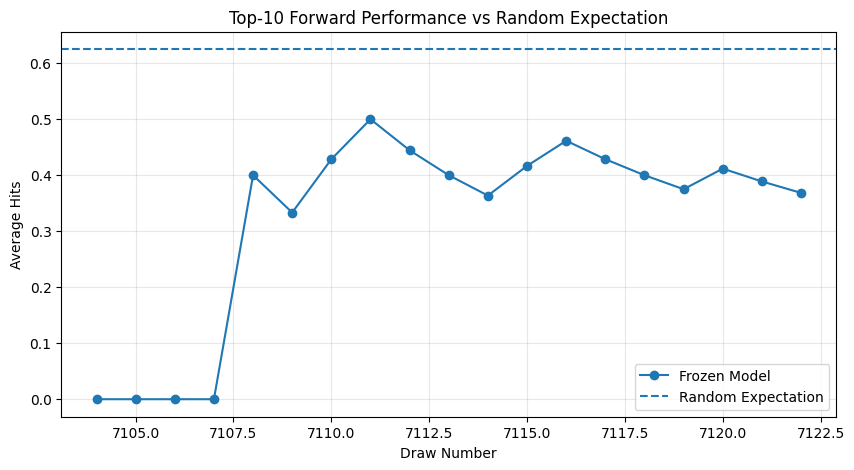

In [25]:
# STEP 20B — Top-10 cumulative performance vs random benchmark

plt.figure(figsize=(10, 5))

plt.plot(
    forward_results["draw"],
    forward_results["cumulative_top10"],
    marker="o",
    label="Frozen Model"
)

plt.axhline(
    y=0.625,
    linestyle="--",
    label="Random Expectation"
)

plt.xlabel("Draw Number")
plt.ylabel("Average Hits")
plt.title("Top-10 Forward Performance vs Random Expectation")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
top10_figure = IMAGE_DIR / "cumulative_top10.png"
plt.savefig(top10_figure, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {top10_figure}")


### Step 20C — Plot Top 15


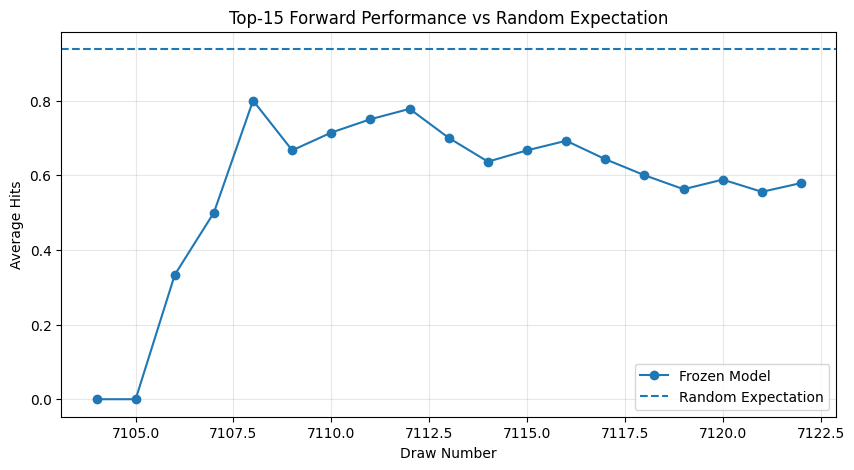

In [26]:
# STEP 20C — Top-15 cumulative performance vs random benchmark

plt.figure(figsize=(10, 5))

plt.plot(
    forward_results["draw"],
    forward_results["cumulative_top15"],
    marker="o",
    label="Frozen Model"
)

plt.axhline(
    y=0.9375,
    linestyle="--",
    label="Random Expectation"
)

plt.xlabel("Draw Number")
plt.ylabel("Average Hits")
plt.title("Top-15 Forward Performance vs Random Expectation")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
top15_figure = IMAGE_DIR / "cumulative_top15.png"
plt.savefig(top15_figure, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {top15_figure}")


### Step 20D — quantify the uncertainty


In [27]:
# STEP 20D — 95% confidence intervals for forward performance

import numpy as np
from scipy import stats

def mean_confidence_interval(data, confidence=0.95):
    data = np.array(data)

    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)

    margin = stats.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    ) * se

    lower = mean - margin
    upper = mean + margin

    return mean, lower, upper


top10_mean, top10_lower, top10_upper = mean_confidence_interval(
    forward_results["top10_hits"]
)

top15_mean, top15_lower, top15_upper = mean_confidence_interval(
    forward_results["top15_hits"]
)


print("95% CONFIDENCE INTERVAL — FORWARD MONITORING")
print("------------------------------------------------")

print(
    f"Top 10: mean = {top10_mean:.3f}, "
    f"95% CI = [{top10_lower:.3f}, {top10_upper:.3f}]"
)

print(
    f"Random expectation = {5 * 10 / 80:.3f}"
)

print()

print(
    f"Top 15: mean = {top15_mean:.3f}, "
    f"95% CI = [{top15_lower:.3f}, {top15_upper:.3f}]"
)

print(
    f"Random expectation = {5 * 15 / 80:.3f}"
)

95% CONFIDENCE INTERVAL — FORWARD MONITORING
------------------------------------------------
Top 10: mean = 0.368, 95% CI = [0.081, 0.656]
Random expectation = 0.625

Top 15: mean = 0.579, 95% CI = [0.286, 0.872]
Random expectation = 0.938


Across the first 19 prospective draws, the frozen model averaged 0.368 Top-10
matches and 0.579 Top-15 matches per draw. Both results were below their random
expectations of 0.625 and 0.9375, respectively.

The 95% interval for Top-10 still includes the random expectation, while the
Top-15 interval ends slightly below it. Because the sample contains only 19
draws and the hit distribution is discrete, these intervals should be treated
as descriptive uncertainty measures rather than definitive proof that the model
is worse than random.


### Prospective-monitoring conclusion

The frozen 45/45/10 model was tested on 19 draws that were unavailable during
model selection and historical holdout evaluation.

- Top-10 average: **0.368**, versus **0.625** expected randomly
- Top-15 average: **0.579**, versus **0.9375** expected randomly

The observed prospective performance was below the random benchmark. Although
19 draws are not enough to estimate long-run performance precisely, the forward
results do not confirm the apparent advantage seen in the historical holdout.
The model remains frozen so future monitoring stays statistically honest.


## 11. Step 21 — Monte Carlo random benchmark

The historical holdout favored the model, whereas the first 19 prospective
draws did not. This section simulates 50,000 random Top-10 and Top-15 strategies
over the same evaluation lengths to show how often chance alone produces results
as strong—or as weak—as those observed.

The simulation reports:

- the model's position within the random distribution;
- the proportion of random simulations that equal or exceed it;
- the central 95% range of random performance; and
- whether the historical result is supported by prospective evidence.


### Step 21A — Create the simulation function


In [28]:
# STEP 21A — Monte Carlo random benchmark function

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def monte_carlo_random_benchmark(
    observed_hits,
    top_k,
    simulations=50_000,
    seed=42
):
    """
    Compare model performance with random Top-K strategies.

    Parameters
    ----------
    observed_hits:
        Model hits for each evaluated draw.

    top_k:
        Size of the ranked list: 10 or 15.

    simulations:
        Number of random experiments.

    seed:
        Makes the simulation reproducible.
    """

    observed_hits = np.asarray(
        observed_hits,
        dtype=int
    )

    number_of_draws = len(observed_hits)

    if number_of_draws == 0:
        raise ValueError(
            "At least one evaluated draw is required."
        )

    if top_k < 1 or top_k > 80:
        raise ValueError(
            "top_k must be between 1 and 80."
        )

    rng = np.random.default_rng(seed)


    # For each simulated strategy and each draw:
    #
    # - There are 80 possible Quina numbers.
    # - top_k numbers are selected by the strategy.
    # - The official draw selects 5 numbers.
    #
    # The hypergeometric distribution calculates
    # how many numbers overlap.
    simulated_hits_per_draw = rng.hypergeometric(
        ngood=top_k,
        nbad=80 - top_k,
        nsample=5,
        size=(simulations, number_of_draws)
    )


    # Total hits produced by every random simulation.
    simulated_total_hits = (
        simulated_hits_per_draw.sum(axis=1)
    )

    simulated_average_hits = (
        simulated_total_hits / number_of_draws
    )


    # Actual frozen-model performance.
    observed_total_hits = int(
        observed_hits.sum()
    )

    observed_average_hits = (
        observed_total_hits / number_of_draws
    )

    random_expected_average = (
        5 * top_k / 80
    )


    # Percentage of random simulations below the model.
    #
    # Example:
    # 97th percentile means the model performed
    # better than approximately 97% of simulations.
    below_model = np.sum(
        simulated_total_hits < observed_total_hits
    )

    equal_to_model = np.sum(
        simulated_total_hits == observed_total_hits
    )

    model_percentile = 100 * (
        below_model + 0.5 * equal_to_model
    ) / simulations


    # Probability that a random strategy equals
    # or exceeds the model.
    empirical_p_value = (
        np.sum(
            simulated_total_hits >= observed_total_hits
        ) + 1
    ) / (simulations + 1)


    # Central 95% range of random performance.
    random_lower_95 = np.quantile(
        simulated_average_hits,
        0.025
    )

    random_upper_95 = np.quantile(
        simulated_average_hits,
        0.975
    )


    results = {
        "Top_K": top_k,
        "Draws": number_of_draws,
        "Simulations": simulations,
        "Model_Total_Hits": observed_total_hits,
        "Model_Average_Hits": observed_average_hits,
        "Random_Expected_Average": random_expected_average,
        "Random_95_Lower": random_lower_95,
        "Random_95_Upper": random_upper_95,
        "Model_Percentile": model_percentile,
        "P_Random_GE_Model": empirical_p_value
    }

    return results, simulated_average_hits

### Step 21B — Simulate the historical holdout


In [29]:
# STEP 21B — Historical holdout Monte Carlo tests

holdout_mc_top10, holdout_simulated_top10 = (
    monte_carlo_random_benchmark(
        observed_hits=holdout_results["top10_hits"],
        top_k=10,
        simulations=50_000,
        seed=42
    )
)


holdout_mc_top15, holdout_simulated_top15 = (
    monte_carlo_random_benchmark(
        observed_hits=holdout_results["top15_hits"],
        top_k=15,
        simulations=50_000,
        seed=43
    )
)


holdout_monte_carlo_summary = pd.DataFrame([
    holdout_mc_top10,
    holdout_mc_top15
])

print("HISTORICAL HOLDOUT — MONTE CARLO RESULTS")

display(
    holdout_monte_carlo_summary.round(4)
)

HISTORICAL HOLDOUT — MONTE CARLO RESULTS


   Top_K  Draws  Simulations  Model_Total_Hits  Model_Average_Hits  \
0     10    200        50000               145               0.725   
1     15    200        50000               219               1.095   

   Random_Expected_Average  Random_95_Lower  Random_95_Upper  \
0                   0.6250            0.525            0.725   
1                   0.9375            0.820            1.055   

   Model_Percentile  P_Random_GE_Model  
0            97.381             0.0292  
1            99.495             0.0057  

### Historical holdout interpretation

For Top-10, the model averaged 0.725 matches per draw versus 0.625 randomly. It
ranked at the 97.381st percentile, and 2.92% of random simulations equaled or
exceeded its total.

For Top-15, the model averaged 1.095 matches per draw versus 0.9375 randomly. It
ranked at the 99.495th percentile, and 0.57% of random simulations equaled or
exceeded its total.

These results show that the holdout performance was historically unusual under
the random benchmark. They do not, by themselves, demonstrate durable future
predictive power; that requires confirmation in prospective data.


### Historical Monte Carlo conclusion

During the 200-draw holdout, the frozen model performed unusually well relative
to the simulated random strategies. The Top-10 result reached the upper edge of
the random 95% range, while the Top-15 result exceeded it. This finding is best
treated as a promising historical result that must be judged alongside the
prospective test below.


### Step 21C — Simulate the forward period


In [30]:
# STEP 21C — Forward-period Monte Carlo tests

forward_mc_top10, forward_simulated_top10 = (
    monte_carlo_random_benchmark(
        observed_hits=forward_results["top10_hits"],
        top_k=10,
        simulations=50_000,
        seed=44
    )
)


forward_mc_top15, forward_simulated_top15 = (
    monte_carlo_random_benchmark(
        observed_hits=forward_results["top15_hits"],
        top_k=15,
        simulations=50_000,
        seed=45
    )
)


forward_monte_carlo_summary = pd.DataFrame([
    forward_mc_top10,
    forward_mc_top15
])

print("FORWARD MONITORING — MONTE CARLO RESULTS")

display(
    forward_monte_carlo_summary.round(4)
)

FORWARD MONITORING — MONTE CARLO RESULTS


   Top_K  Draws  Simulations  Model_Total_Hits  Model_Average_Hits  \
0     10     19        50000                 7              0.3684   
1     15     19        50000                11              0.5789   

   Random_Expected_Average  Random_95_Lower  Random_95_Upper  \
0                   0.6250           0.3158           0.9474   
1                   0.9375           0.5789           1.3158   

   Model_Percentile  P_Random_GE_Model  
0             5.343             0.9664  
1             2.925             0.9804  

### Prospective Monte Carlo interpretation

During the first 19 prospective draws, the frozen model produced 7 Top-10 hits
and 11 Top-15 hits, corresponding to average hit rates of 0.3684 and 0.5789.
Both were below their random expectations of 0.6250 and 0.9375.

The Top-10 result ranked at approximately the 5.34th percentile of random
simulations, and the Top-15 result ranked at approximately the 2.93rd
percentile. Random strategies equaled or exceeded the model in approximately
96.64% and 98.04% of simulations, respectively.

The observed values remained at or within the simulated central 95% random
ranges. Consequently, the strong historical holdout result has not been
confirmed prospectively. Continued monitoring may narrow the uncertainty, but
the current evidence does not justify claiming predictive superiority.


## 12. Step 22 — Experimental Monte Carlo number selection

### Purpose

This section converts the frozen model scores into sampling weights and uses
them to generate 100,000 experimental five-number tickets. Numbers with higher
model scores appear more often in the simulation.

Outputs include a model-weighted Top-10 and Top-15, selection frequencies,
sample five-number combinations, and a model-strength ranking.

This procedure does **not** create an independent source of predictive evidence:
it redistributes the existing 45/45/10 scores into candidate tickets. Selection
rates, strength scores, percentiles, and ranks describe the model's preferences;
they are not official Quina winning probabilities.


### Step 22A — Rebuild the latest scores


In [31]:
# STEP 22A — Rebuild the latest 45/45/10 scores

# Use all currently available completed draws.
historical_counts, history_numbers, last_seen = (
    initialize_history(df_quina)
)

latest_completed_draw = int(
    df_quina["draw_number"].max()
)


monte_carlo_score_df = build_feature_table(
    historical_counts=historical_counts,
    history_numbers=history_numbers,
    last_seen=last_seen,
    training_end_draw=latest_completed_draw
)


# Apply the frozen 45/45/10 weights.
monte_carlo_score_df["Final_Score"] = (
    best_weights["frequency"]
    * monte_carlo_score_df["frequency_scaled"]

    + best_weights["recent"]
    * monte_carlo_score_df["recent_scaled"]

    + best_weights["gap"]
    * monte_carlo_score_df["gap_scaled"]
)


monte_carlo_score_df = (
    monte_carlo_score_df
    .sort_values(
        ["Final_Score", "number"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)


print(
    "Latest completed draw:",
    latest_completed_draw
)

print(
    "Monte Carlo selections will target draw:",
    latest_completed_draw + 1
)

print("Frozen model:", best_model_name)
print("Frozen weights:", best_weights)


display(
    monte_carlo_score_df[
        [
            "number",
            "frequency",
            "Recent_Score",
            "current_gap",
            "Final_Score"
        ]
    ].head(15)
)

Latest completed draw: 7122
Monte Carlo selections will target draw: 7123
Frozen model: Freq45_Recent45_Gap10
Frozen weights: {'frequency': 0.45, 'recent': 0.45, 'gap': 0.1}


    number  frequency  Recent_Score  current_gap  Final_Score
0       26      497.0        0.0908         19.0     0.826600
1       66      469.0        0.0990          2.0     0.729394
2        4      509.0        0.0648         14.0     0.711246
3       14      460.0        0.0986         12.0     0.711197
4       61      460.0        0.0982          7.0     0.698841
5       16      478.0        0.0840          6.0     0.684884
6       42      474.0        0.0800         23.0     0.679394
7       29      479.0        0.0796         14.0     0.678950
8       49      486.0        0.0722         15.0     0.665240
9       33      467.0        0.0850          0.0     0.634968
10      78      444.0        0.0976          6.0     0.629590
11      54      456.0        0.0860          5.0     0.607053
12      17      424.0        0.0976         24.0     0.585944
13      27      435.0        0.0940         10.0     0.580545
14       9      470.0        0.0688          6.0     0.563497

### Step 22B — Convert model scores into sampling weights


In [32]:
# STEP 22B — Convert final scores into sampling weights

# A tiny positive value prevents any number from
# having an absolute zero probability in the simulation.
EPSILON = 1e-9

monte_carlo_score_df["Sampling_Weight"] = (
    monte_carlo_score_df["Final_Score"]
    + EPSILON
)


monte_carlo_score_df["Sampling_Probability"] = (
    monte_carlo_score_df["Sampling_Weight"]
    / monte_carlo_score_df["Sampling_Weight"].sum()
)


print(
    "Sum of sampling probabilities:",
    monte_carlo_score_df[
        "Sampling_Probability"
    ].sum()
)


display(
    monte_carlo_score_df[
        [
            "number",
            "Final_Score",
            "Sampling_Probability"
        ]
    ].head(15)
)

Sum of sampling probabilities: 0.9999999999999998


    number  Final_Score  Sampling_Probability
0       26     0.826600              0.023341
1       66     0.729394              0.020596
2        4     0.711246              0.020084
3       14     0.711197              0.020082
4       61     0.698841              0.019733
5       16     0.684884              0.019339
6       42     0.679394              0.019184
7       29     0.678950              0.019172
8       49     0.665240              0.018784
9       33     0.634968              0.017930
10      78     0.629590              0.017778
11      54     0.607053              0.017141
12      17     0.585944              0.016545
13      27     0.580545              0.016393
14       9     0.563497              0.015912

### Step 22C — Generate 100,000 simulated tickets


In [33]:
# STEP 22C — Generate Monte Carlo tickets

NUMBER_OF_SIMULATIONS = 100_000
NUMBERS_PER_TICKET = 5
MONTE_CARLO_SEED = 2026


rng = np.random.default_rng(
    MONTE_CARLO_SEED
)


available_numbers = (
    monte_carlo_score_df["number"]
    .astype(int)
    .to_numpy()
)


sampling_probabilities = (
    monte_carlo_score_df[
        "Sampling_Probability"
    ]
    .to_numpy()
)


simulated_tickets = np.empty(
    (
        NUMBER_OF_SIMULATIONS,
        NUMBERS_PER_TICKET
    ),
    dtype=int
)


for simulation_number in range(
    NUMBER_OF_SIMULATIONS
):

    ticket = rng.choice(
        available_numbers,
        size=NUMBERS_PER_TICKET,
        replace=False,
        p=sampling_probabilities
    )

    simulated_tickets[
        simulation_number
    ] = np.sort(ticket)


print(
    f"{NUMBER_OF_SIMULATIONS:,} "
    "five-number tickets generated."
)

print()
print("First 10 simulated tickets:")

display(
    pd.DataFrame(
        simulated_tickets[:10],
        columns=[
            "Number_1",
            "Number_2",
            "Number_3",
            "Number_4",
            "Number_5"
        ]
    )
)

100,000 five-number tickets generated.

First 10 simulated tickets:


   Number_1  Number_2  Number_3  Number_4  Number_5
0        15        38        43        49        63
1        13        36        39        49        62
2        11        40        43        59        60
3         2         9        32        44        54
4        26        46        56        57        71
5        31        33        38        39        56
6        15        21        25        34        78
7        55        57        72        76        79
8        18        27        40        54        55
9        30        33        47        52        73

### Step 22D — Calculate simulated selection frequencies


In [34]:
# STEP 22D — Count how frequently each number was selected

selection_counts = np.bincount(
    simulated_tickets.flatten(),
    minlength=81
)[1:]


monte_carlo_frequency_df = pd.DataFrame({
    "number": np.arange(1, 81),
    "Simulation_Count": selection_counts
})


monte_carlo_frequency_df[
    "Simulation_Selection_Rate"
] = (
    monte_carlo_frequency_df[
        "Simulation_Count"
    ]
    / NUMBER_OF_SIMULATIONS
)


monte_carlo_results = (
    monte_carlo_score_df.merge(
        monte_carlo_frequency_df,
        on="number",
        how="left"
    )
)


monte_carlo_results = (
    monte_carlo_results
    .sort_values(
        [
            "Simulation_Selection_Rate",
            "Final_Score",
            "number"
        ],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)


monte_carlo_results.index = (
    monte_carlo_results.index + 1
)

monte_carlo_results.index.name = (
    "Monte_Carlo_Rank"
)


display(
    monte_carlo_results[
        [
            "number",
            "Final_Score",
            "Simulation_Count",
            "Simulation_Selection_Rate",
            "frequency",
            "Recent_Score",
            "current_gap"
        ]
    ].head(15)
)

                  number  Final_Score  Simulation_Count  \
Monte_Carlo_Rank                                          
1                     26     0.826600             11467   
2                     66     0.729394             10173   
3                      4     0.711246             10067   
4                     14     0.711197              9843   
5                     16     0.684884              9816   
6                     61     0.698841              9804   
7                     29     0.678950              9625   
8                     42     0.679394              9591   
9                     49     0.665240              9338   
10                    78     0.629590              8807   
11                    33     0.634968              8758   
12                    54     0.607053              8470   
13                    17     0.585944              8306   
14                    27     0.580545              8103   
15                     5     0.557061              7996 

### Step 22E — Produce Monte Carlo Top 10 and Top 15


In [35]:
# STEP 22E — Monte Carlo Top-10 and Top-15

monte_carlo_top10 = (
    monte_carlo_results["number"]
    .head(10)
    .astype(int)
    .tolist()
)


monte_carlo_top15 = (
    monte_carlo_results["number"]
    .head(15)
    .astype(int)
    .tolist()
)


print(
    "MONTE CARLO NUMBER-SELECTION RESULTS"
)

print("-" * 45)

print(
    "Data available through draw:",
    latest_completed_draw
)

print(
    "Selections generated for draw:",
    latest_completed_draw + 1
)

print(
    "Simulations:",
    f"{NUMBER_OF_SIMULATIONS:,}"
)

print()
print("Monte Carlo Top 10:")
print(monte_carlo_top10)

print()
print("Monte Carlo Top 15:")
print(monte_carlo_top15)

MONTE CARLO NUMBER-SELECTION RESULTS
---------------------------------------------
Data available through draw: 7122
Selections generated for draw: 7123
Simulations: 100,000

Monte Carlo Top 10:
[26, 66, 4, 14, 16, 61, 29, 42, 49, 78]

Monte Carlo Top 15:
[26, 66, 4, 14, 16, 61, 29, 42, 49, 78, 33, 54, 17, 27, 5]


### Step 22F — Generate example five-number combinations


In [36]:
# STEP 22F — Generate unique portfolio sample combinations

NUMBER_OF_SAMPLE_TICKETS = 10

sample_rng = np.random.default_rng(2027)

sample_tickets = set()


while len(sample_tickets) < NUMBER_OF_SAMPLE_TICKETS:

    ticket = sample_rng.choice(
        available_numbers,
        size=5,
        replace=False,
        p=sampling_probabilities
    )

    ticket = tuple(
        sorted(int(number) for number in ticket)
    )

    sample_tickets.add(ticket)


sample_tickets_df = pd.DataFrame(
    sorted(sample_tickets),
    columns=[
        "Number_1",
        "Number_2",
        "Number_3",
        "Number_4",
        "Number_5"
    ]
)


sample_tickets_df.index = (
    sample_tickets_df.index + 1
)

sample_tickets_df.index.name = (
    "Experimental_Ticket"
)


print(
    "EXPERIMENTAL MONTE CARLO COMBINATIONS"
)

display(sample_tickets_df)


EXPERIMENTAL MONTE CARLO COMBINATIONS


                     Number_1  Number_2  Number_3  Number_4  Number_5
Experimental_Ticket                                                  
1                           2        30        39        54        80
2                           3         4        33        42        64
3                           8        26        41        66        76
4                          10        12        31        33        64
5                          11        15        42        43        78
6                          14        24        26        41        44
7                          15        43        49        52        61
8                          15        51        58        63        65
9                          18        39        52        61        72
10                         21        61        62        65        66

### Step 22H — Rank tickets by model strength


In [37]:
# STEP 22H-1 — Create a lookup for each number's model score

number_score_lookup = dict(
    zip(
        monte_carlo_score_df["number"].astype(int),
        monte_carlo_score_df["Final_Score"]
    )
)


print("Example model scores:")

for number in list(number_score_lookup.keys())[:5]:

    print(
        f"Number {number}: "
        f"{number_score_lookup[number]:.6f}"
    )

Example model scores:
Number 26: 0.826600
Number 66: 0.729394
Number 4: 0.711246
Number 14: 0.711197
Number 61: 0.698841


In [38]:
# STEP 22H-2 — Calculate strength scores for all simulations

# Create an array in which the position represents
# the Quina number.
score_array = np.zeros(81)


for number, score in number_score_lookup.items():

    score_array[int(number)] = score


# Retrieve the five model scores inside every ticket
# and calculate their average.
all_simulated_ticket_strengths = (
    score_array[simulated_tickets]
    .mean(axis=1)
)


print(
    "Simulated tickets scored:",
    len(all_simulated_ticket_strengths)
)

print(
    "Average strength across simulations:",
    round(
        all_simulated_ticket_strengths.mean(),
        6
    )
)

print(
    "Lowest simulated strength:",
    round(
        all_simulated_ticket_strengths.min(),
        6
    )
)

print(
    "Highest simulated strength:",
    round(
        all_simulated_ticket_strengths.max(),
        6
    )
)

Simulated tickets scored: 100000
Average strength across simulations: 0.489417
Lowest simulated strength: 0.254317
Highest simulated strength: 0.728735


In [39]:
# STEP 22H-3 — Calculate each sample ticket's model strength

ticket_columns = [
    "Number_1",
    "Number_2",
    "Number_3",
    "Number_4",
    "Number_5"
]


ranked_sample_tickets = (
    sample_tickets_df
    .reset_index(drop=True)
    .copy()
)


def calculate_ticket_strength(row):

    ticket_scores = [
        number_score_lookup[int(row[column])]
        for column in ticket_columns
    ]

    return np.mean(ticket_scores)


ranked_sample_tickets[
    "Model_Strength_Score"
] = ranked_sample_tickets.apply(
    calculate_ticket_strength,
    axis=1
)


display(
    ranked_sample_tickets.round(6)
)

   Number_1  Number_2  Number_3  Number_4  Number_5  Model_Strength_Score
0         2        30        39        54        80              0.498257
1         3         4        33        42        64              0.524760
2         8        26        41        66        76              0.525302
3        10        12        31        33        64              0.447346
4        11        15        42        43        78              0.509908
5        14        24        26        41        44              0.613751
6        15        43        49        52        61              0.557217
7        15        51        58        63        65              0.399640
8        18        39        52        61        72              0.515298
9        21        61        62        65        66              0.462186

In [40]:
# STEP 22H-4 — Compare each ticket with all simulations

sorted_simulated_strengths = np.sort(
    all_simulated_ticket_strengths
)


def calculate_strength_percentile(
    ticket_strength
):

    number_below_or_equal = np.searchsorted(
        sorted_simulated_strengths,
        ticket_strength,
        side="right"
    )

    percentile = (
        100
        * number_below_or_equal
        / len(sorted_simulated_strengths)
    )

    return percentile


ranked_sample_tickets[
    "Model_Strength_Percentile"
] = (
    ranked_sample_tickets[
        "Model_Strength_Score"
    ].apply(
        calculate_strength_percentile
    )
)

In [41]:
# STEP 22H-5 — Rank from strongest to weakest

ranked_sample_tickets = (
    ranked_sample_tickets
    .sort_values(
        [
            "Model_Strength_Score",
            "Number_1",
            "Number_2",
            "Number_3",
            "Number_4",
            "Number_5"
        ],
        ascending=[
            False,
            True,
            True,
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)


ranked_sample_tickets.index = (
    ranked_sample_tickets.index + 1
)

ranked_sample_tickets.index.name = (
    "Model_Favored_Rank"
)


print(
    "MODEL-RANKED MONTE CARLO COMBINATIONS"
)

print(
    "Target draw:",
    latest_completed_draw + 1
)


display(
    ranked_sample_tickets.round({
        "Model_Strength_Score": 6,
        "Model_Strength_Percentile": 2
    })
)

MODEL-RANKED MONTE CARLO COMBINATIONS
Target draw: 7123


                    Number_1  Number_2  Number_3  Number_4  Number_5  \
Model_Favored_Rank                                                     
1                         14        24        26        41        44   
2                         15        43        49        52        61   
3                          8        26        41        66        76   
4                          3         4        33        42        64   
5                         18        39        52        61        72   
6                         11        15        42        43        78   
7                          2        30        39        54        80   
8                         21        61        62        65        66   
9                         10        12        31        33        64   
10                        15        51        58        63        65   

                    Model_Strength_Score  Model_Strength_Percentile  
Model_Favored_Rank                                               

### Step 22 conclusion

Using data through draw 7122, the frozen 45/45/10 model generated 100,000
experimental five-number tickets for draw 7123. Higher-scoring numbers received
larger sampling weights, after which the simulated tickets were summarized into
Top-10 and Top-15 rankings.

Ten example combinations were also ranked by their average Model Strength
Score. The Model Strength Percentile compares each ticket only with the 100,000
model-weighted simulations. It must not be interpreted as the probability that
the ticket will win.

In a fair Quina drawing, every exact five-number combination retains the same
jackpot probability. These outputs are therefore an experimental selection aid,
not a proven forecast of the next result.


## 13. Final conclusion

The project successfully built a reproducible pipeline for acquiring, validating,
analyzing, and prospectively testing Quina data. The 45/45/10 model produced an
encouraging result in one 200-draw historical holdout, but its performance fell
below the random benchmark in the subsequent 19 unseen draws.

Accordingly, the analysis found **no stable evidence that historical frequency,
recent frequency, or gap information can reliably predict future Quina
numbers**. The model-weighted rankings may be used as transparent experimental
selections, provided that they are not described as superior winning
probabilities.

This is a meaningful analytical result: the project separated model selection,
historical validation, and prospective monitoring; avoided look-ahead leakage;
quantified uncertainty; and reported when an apparent historical signal did not
persist out of sample.

### Responsible interpretation

> This model is an experimental historical-ranking system. It does not guarantee
> winnings and has not demonstrated stable predictive superiority over random
> selection in prospective testing. Play should remain recreational and within
> a predetermined budget.


In [ ]:
# Export the experimental model-ranked selections to a portable Excel file.
selection_table = ranked_sample_tickets.reset_index().copy()
selection_table.insert(1, "Target_Draw", latest_completed_draw + 1)

selection_table = selection_table.rename(columns={
    "Model_Favored_Rank": "Model Rank",
    "Target_Draw": "Target Draw",
    "Number_1": "Number 1",
    "Number_2": "Number 2",
    "Number_3": "Number 3",
    "Number_4": "Number 4",
    "Number_5": "Number 5",
    "Model_Strength_Score": "Model Strength Score",
    "Model_Strength_Percentile": "Model Strength Percentile",
})

selection_table["Model Strength Score"] = (
    selection_table["Model Strength Score"].round(4)
)
selection_table["Model Strength Percentile"] = (
    selection_table["Model Strength Percentile"].round(2)
)

method_notes = pd.DataFrame({
    "Important Notes": [
        "Generated using 100,000 Monte Carlo simulations.",
        "Model weights: 45% historical frequency, 45% recent frequency, 10% gap.",
        "Model Strength Score is not an official winning probability.",
        "Every exact five-number combination has the same jackpot probability in a fair draw.",
        "Selections are experimental and are not gambling advice.",
    ]
})

excel_path = OUTPUT_DIR / (
    f"quina_model_ranked_selections_draw_{latest_completed_draw + 1}.xlsx"
)

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    selection_table.to_excel(
        writer, sheet_name="Model Ranked Tickets", index=False
    )
    method_notes.to_excel(
        writer, sheet_name="Method and Disclaimer", index=False
    )

print(f"Excel report created: {excel_path.resolve()}")
